<a href="https://colab.research.google.com/github/alessiomartini/learning_econophysics/blob/main/The_Ornstein_Uhlenbeck_process.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 2 : The Ornstein-Uhlenbeck process

from: Tutorial 1: Time series simulation and analysis ECO 586/PHY 560C Modelling Financial Markets: an Introduction to Econophysics MICHAEL BENZAQUEN

The Ornstein-Uhlenbeck process (centered around 0) is defined by the following SDE (stochastic differential eq):

1.   dx(t)/dt = −ωx(t) + σξ(t)
2.   〈ξ(t)ξ(t_0)〉 = δ(t − t_0)

We remind that the discretization according to the Ito prescription of this SDE is given by: (UNDERSTAND IT!)

x(N+1)∆t = xN∆t
(1 − ω∆t) + σ
p
∆tξN

where the ξN variables are normally distributed with variance 1.



In [ ]:
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
import csv

1. Write a function ornstein_uhlenbeck(x_0, omega, sigma, dt, T) that returns a realisation of the Ornstein-Uhlenbeck process with initial condition x0 and with parameters ω and σ
over T steps with a discretization dt.


In [ ]:
def ornstein_uhlenbeck(x_0, omega, sigma, dt, T):
    """
    Generates a realization of the Ornstein-Uhlenbeck process.

    Args:
        x_0 (float): Initial condition.
        omega (float): Parameter omega.
        sigma (float): Parameter sigma.
        dt (float): Discretization step.
        T (int): Total number of steps.

    Returns:
        numpy.ndarray: A 1D array representing the realization of the O-U process.
    """
    x = np.zeros(T)
    x[0] = x_0
    for i in range(T - 1):
        # ξN variables are normally distributed with variance 1, so std dev is 1
        xi_N = np.random.normal(loc=0.0, scale=1.0)
        x[i+1] = x[i] * (1 - omega * dt) + sigma * np.sqrt(dt) * xi_N
    return x

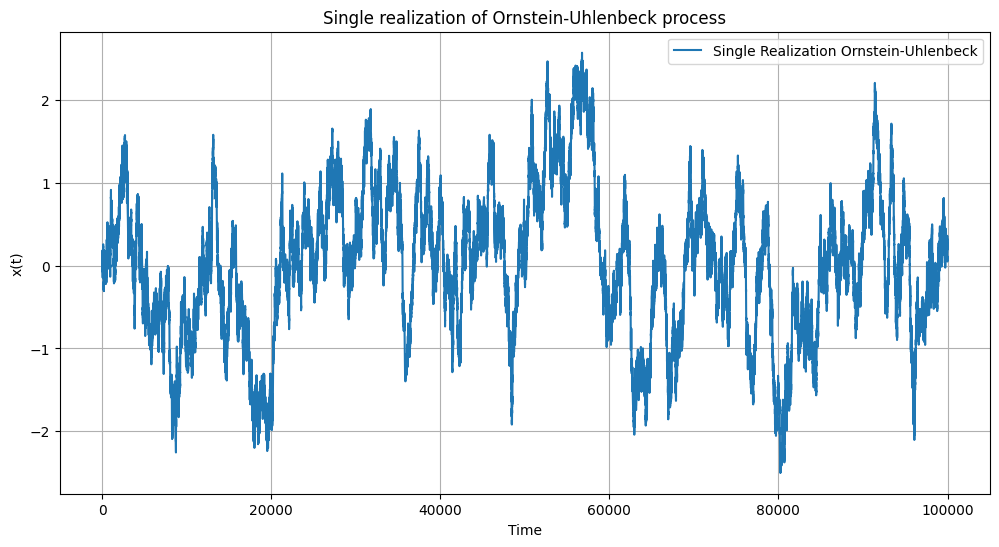

In [ ]:
# Generate a single Ornstein-Uhlenbeck realization using the ornstein_uhlenbeck function
single_ou_realization = ornstein_uhlenbeck(x_0=0.0, omega=omega, sigma=sigma, dt=dt, T=T)

plt.figure(figsize=(12, 6))
plt.plot(single_ou_realization, label='Single Realization Ornstein-Uhlenbeck')

plt.title('Single realization of Ornstein-Uhlenbeck process')
plt.xlabel('Time')
plt.ylabel('x(t)')
plt.legend()
plt.grid(True)
plt.show()

2. **To generate statistics over the Ornstein-Uhlenbeck process it is necessary to generate many instances of it.**
Write a new function N_ornstein_uhlenbeck(x_0, omega, sigma, dt, N, T)
that generates a T × N array where each column is a realisation of the O-U process with corresponding parameters. The x0
initial condition is now a vector of size N.

*We remind that in
Python a[i,:] accesses the i-th row of array a, and a[:,j] its j-th column.*


In [ ]:
def N_ornstein_uhlenbeck(x_0, omega, sigma, dt, N, T):
    """
    Generates N realizations of the Ornstein-Uhlenbeck process.

    Args:
        x_0 (numpy.ndarray): Initial condition vector of size N.
        omega (float): Parameter omega.
        sigma (float): Parameter sigma.
        dt (float): Discretization step.
        N (int): Number of realizations.
        T (int): Total number of steps for each realization.

    Returns:
        numpy.ndarray: A T x N array where each column is a realization of the O-U process.
    """
    x_processes = np.zeros((T, N))
    x_processes[0, :] = x_0   # this is a vector equation

    for i in range(T - 1):
        # Generate N standard normal random variables for each step, one for each process
        xi_N_vector = np.random.normal(loc=0.0, scale=1.0, size=N)
        x_processes[i+1, :] = x_processes[i, :] * (1 - omega * dt) + sigma * np.sqrt(dt) * xi_N_vector
        # this is the row updating
    return x_processes

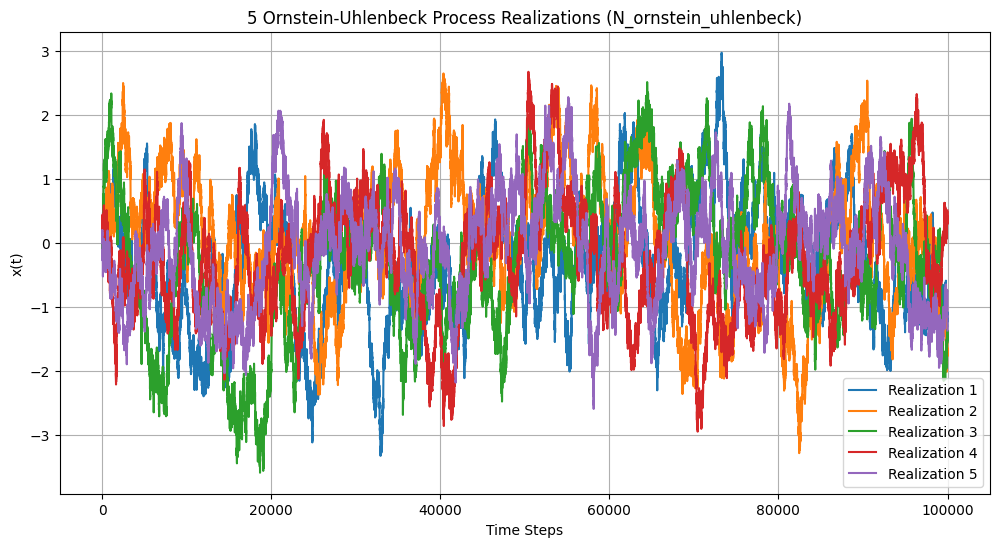

In [ ]:
N_plot = 5 # Number of realizations to plot
x_0_plot = np.zeros(N_plot) # Initial conditions for these 5 realizations

# Generate 5 realizations using N_ornstein_uhlenbeck
ou_processes_plot = N_ornstein_uhlenbeck(x_0_plot, omega, sigma, dt, N_plot, T)

plt.figure(figsize=(12, 6))
for i in range(N_plot):
    plt.plot(ou_processes_plot[:, i], label=f'Realization {i+1}')

plt.title('5 Ornstein-Uhlenbeck Process Realizations (N_ornstein_uhlenbeck)')
plt.xlabel('Time Steps')
plt.ylabel('x(t)')
plt.legend()
plt.grid(True)
plt.show()

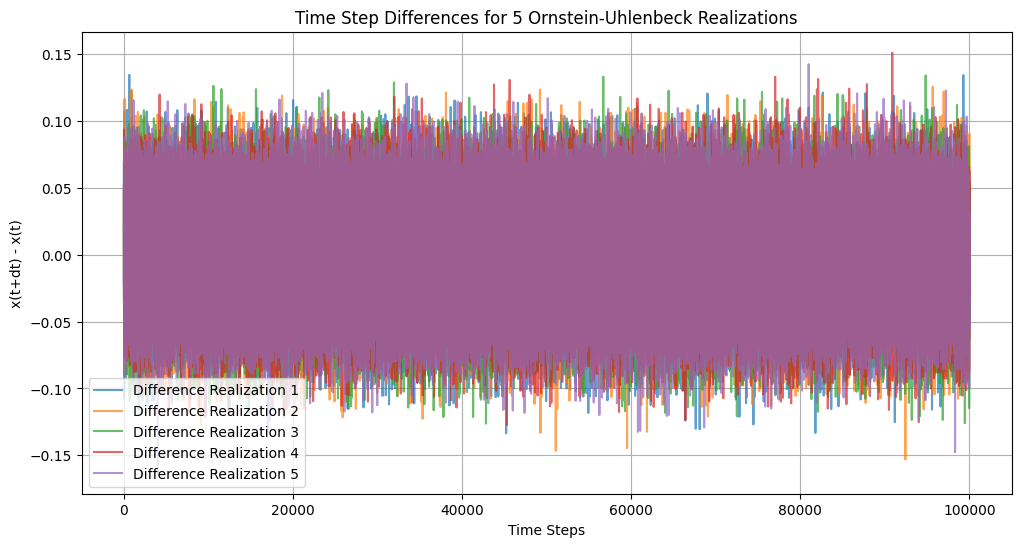

In [ ]:
# Part 1: Plot 5 simulations with time step differences
# Use ou_processes_plot which already has 5 realizations

# Calculate differences for each of the 5 realizations along the time axis
diffs = np.diff(ou_processes_plot, axis=0)

plt.figure(figsize=(12, 6))
for i in range(diffs.shape[1]):
    plt.plot(diffs[:, i], label=f'Difference Realization {i+1}', alpha=0.7)

plt.title('Time Step Differences for 5 Ornstein-Uhlenbeck Realizations')
plt.xlabel('Time Steps')
plt.ylabel('x(t+dt) - x(t)')
plt.legend()
plt.grid(True)
plt.show()

3. Show that the solution of the Ornstein-Uhlenbeck process is given by
x(t) = x(0)e
−ωt + σ
Z t
0
ds e−ω(t−s)ξ(s). (9.12)


To show that the solution of the Ornstein-Uhlenbeck process is given by $x(t) = x(0)e^{-\omega t} + \sigma \int_{0}^{t} ds e^{-\omega(t-s)}\xi(s)$, we can use an integrating factor method. Here's the derivation:

Given the SDE:

$$\frac{dx(t)}{dt} = -\omega x(t) + \sigma \xi(t)$$

This can be rewritten as:

$$\frac{dx(t)}{dt} + \omega x(t) = \sigma \xi(t)$$

This is a first-order linear non-homogeneous differential equation. We can solve it using an integrating factor. The integrating factor is $e^{\int \omega dt} = e^{\omega t}$.

Multiply the entire equation by the integrating factor:

$$e^{\omega t} \frac{dx(t)}{dt} + \omega e^{\omega t} x(t) = \sigma e^{\omega t}\xi(t)$$

The left side of the equation is the derivative of the product $x(t)e^{\omega t}$ with respect to $t$:

$$\frac{d}{dt} [x(t)e^{\omega t}] = \sigma e^{\omega t}\xi(t)$$

Now, integrate both sides from $0$ to $t$:

$$\int_{0}^{t} \frac{d}{ds} [x(s)e^{\omega s}] ds = \int_{0}^{t} \sigma e^{\omega s}\xi(s) ds$$

Applying the fundamental theorem of calculus to the left side:

$$x(t)e^{\omega t} - x(0)e^{\omega 0} = \int_{0}^{t} \sigma e^{\omega s}\xi(s) ds$$

Since $e^{\omega 0} = 1$:

$$x(t)e^{\omega t} - x(0) = \int_{0}^{t} \sigma e^{\omega s}\xi(s) ds$$

Now, isolate $x(t)e^{\omega t}$:

$$x(t)e^{\omega t} = x(0) + \int_{0}^{t} \sigma e^{\omega s}\xi(s) ds$$

Finally, multiply by $e^{-\omega t}$ to solve for $x(t)$:

$$x(t) = x(0)e^{-\omega t} + e^{-\omega t} \int_{0}^{t} \sigma e^{\omega s}\xi(s) ds$$

We can move $e^{-\omega t}$ inside the integral. Since $e^{-\omega t}$ is constant with respect to $s$ (the integration variable), it becomes $e^{-\omega t}e^{\omega s} = e^{-\omega(t-s)}$:

$$x(t) = x(0)e^{-\omega t} + \sigma \int_{0}^{t} ds e^{-\omega(t-s)}\xi(s)$$

This matches the given solution.

4. Now show that 〈x(t)〉 −→t→∞0. Taking x(0) = 0 for simplicity, compute the product x(t)x(t + τ)
and average it over ξ to recover the correlation function:
C(t,τ) = 〈x(t)x(t + τ)〉 =
σ
2
2ω

e
−ω|τ| − e
−ω(2t+τ)

. (9.13)
Comment on its behavior at long times.


We start with the analytical solution of the Ornstein-Uhlenbeck process, assuming $x(0) = 0$ as stated in the problem:

$$x(t) = \sigma \int_{0}^{t} ds e^{-\omega(t-s)}\xi(s)$$

### Showing that $\langle x(t) \rangle \to 0$ as $t \to \infty$ {i.e. unbroken phase}

To find the expectation value of $x(t)$, we take the ensemble average:

$$\langle x(t) \rangle = \left\langle \sigma \int_{0}^{t} ds e^{-\omega(t-s)}\xi(s) \right\rangle$$

Since $\sigma$ and $e^{-\omega(t-s)}$ are deterministic (not random), we can move the expectation operator inside the integral:

$$\langle x(t) \rangle = \sigma \int_{0}^{t} ds e^{-\omega(t-s)} \langle\xi(s)\rangle$$

For white noise $\xi(s)$, its ensemble average is zero, i.e., $\langle\xi(s)\rangle = 0$. Therefore:

$$\langle x(t) \rangle = \sigma \int_{0}^{t} ds e^{-\omega(t-s)} \cdot 0 = 0$$

So, $\langle x(t) \rangle = 0$ for all $t$ when $x(0)=0$

*(if we didn't set $x_0 =0$ we would have obtained $\langle x(t) \rangle = x_0$).*

This implies that $\langle x(t) \rangle \to 0$ as $t \to \infty$.

### Computing the Correlation Function $C(t,\tau) = \langle x(t)x(t + \tau) \rangle$

Let $t' = t + \tau$. We need to compute $C(t, t') = \langle x(t)x(t') \rangle$. Using the solution for $x(t)$:

$$x(t) = \sigma \int_{0}^{t} ds_1 e^{-\omega(t-s_1)}\xi(s_1)$$
$$x(t') = \sigma \int_{0}^{t'} ds_2 e^{-\omega(t'-s_2)}\xi(s_2)$$

Then the correlation function is:

$$C(t, t') = \left\langle \sigma \int_{0}^{t} ds_1 e^{-\omega(t-s_1)}\xi(s_1) \cdot \sigma \int_{0}^{t'} ds_2 e^{-\omega(t'-s_2)}\xi(s_2) \right\rangle$$

Move $\sigma^2$ and the integrals outside the expectation:

$$C(t, t') = \sigma^2 \int_{0}^{t} ds_1 \int_{0}^{t'} ds_2 e^{-\omega(t-s_1)} e^{-\omega(t'-s_2)} \langle\xi(s_1)\xi(s_2)\rangle$$

For white noise, the correlation is given by $\langle\xi(s_1)\xi(s_2)\rangle = \delta(s_1 - s_2)$, where $\delta$ is the Dirac delta function. Substituting this into the equation:

$$C(t, t') = \sigma^2 \int_{0}^{t} ds_1 \int_{0}^{t'} ds_2 e^{-\omega(t-s_1)} e^{-\omega(t'-s_2)} \delta(s_1 - s_2)$$

The integral over $s_2$ with the delta function sets $s_2 = s_1$, provided $s_1$ is within the integration limits $[0, t']$. Similarly, $s_1$ must be within $[0, t]$. Thus, the effective integration range for $s_1$ is $[0, \min(t, t')]$.

$$C(t, t') = \sigma^2 \int_{0}^{\min(t, t')} ds_1 e^{-\omega(t-s_1)} e^{-\omega(t'-s_1)}$$
$$C(t, t') = \sigma^2 \int_{0}^{\min(t, t')} ds_1 e^{-\omega(t+t'-2s_1)}$$
$$C(t, t') = \sigma^2 e^{-\omega(t+t')} \int_{0}^{\min(t, t')} ds_1 e^{2\omega s_1}$$

Evaluate the integral:

$$C(t, t') = \sigma^2 e^{-\omega(t+t')} \left[ \frac{e^{2\omega s_1}}{2\omega} \right]_{0}^{\min(t, t')}$$
$$C(t, t') = \frac{\sigma^2}{2\omega} e^{-\omega(t+t')} (e^{2\omega \min(t, t')} - e^{0})$$
$$C(t, t') = \frac{\sigma^2}{2\omega} (e^{-\omega(t+t') + 2\omega \min(t, t')} - e^{-\omega(t+t')})$$

Now substitute $t' = t + \tau$:

- If $\tau \ge 0$, then $t' \ge t$, so $\min(t, t') = t$. The first term in the parenthesis becomes $e^{-\omega(t+t+\tau) + 2\omega t} = e^{-\omega(2t+\tau) + 2\omega t} = e^{-\omega\tau}$.
- If $\tau < 0$, then $t' < t$, so $\min(t, t') = t'$. The first term becomes $e^{-\omega(t+t') + 2\omega t'} = e^{-\omega t + \omega t'} = e^{-\omega(t-t')} = e^{-\omega|\tau|}$.

Both cases can be covered using $|\tau|$:

$$C(t, \tau) = \frac{\sigma^2}{2\omega} (e^{-\omega|\tau|} - e^{-\omega(2t+\tau)})$$

This matches the given correlation function.

### Behavior at Long Times

We examine the behavior of $C(t,\tau)$ as $t \to \infty$, assuming $\omega > 0$ for the process to be stable (small variation in initaial data equal small variation in outcome) and mean-reverting (there is an attractive force to the mean value):

$$\lim_{t \to \infty} C(t, \tau) = \lim_{t \to \infty} \frac{\sigma^2}{2\omega} (e^{-\omega|\tau|} - e^{-\omega(2t+\tau)})$$

As $t \to \infty$, the term $e^{-\omega(2t+\tau)}$ approaches $0$. Therefore, the correlation function tends to a stationary value:

$$C_{stationary}(\tau) = \frac{\sigma^2}{2\omega} e^{-\omega|\tau|}$$

**Comment on its behavior at long times:**

At long times, the Ornstein-Uhlenbeck process becomes stationary, meaning its statistical properties (like the correlation function) no longer depend on the absolute time $t$, but only on the time difference $\tau$. The correlation function decays exponentially with the absolute time difference $|\tau|$.

- The decay rate is determined by $\omega$: a larger $\omega$ means faster decay of correlations (shorter memory), and a smaller $\omega$ means slower decay (longer memory).
- The prefactor $\frac{\sigma^2}{2\omega}$ represents the variance of the process in the stationary state. It indicates that higher noise intensity (larger $\sigma$) or weaker restoring force (smaller $\omega$) leads to larger fluctuations.

This exponential decay of correlation is a characteristic feature of Markovian processes, where the future state depends only on the present state and not on the past history.

5. Create a DataFrame df where each row is a time point and with 100 columns corresponding
to an instance of an Ornstein-Uhlenbeck process with σ = 1 and your choice of ω. (hint: use
pd.DataFrame(x) where x is the output of a function you have defined). Take again $T = 10^5$
and $dt = 10^{−3}$
.


In [ ]:
N = 100 # 100 columns (realizations)
T = 10**5 # Total number of steps
dt = 10**-3 # Discretization step
sigma = 1 # Parameter sigma
omega = 0.5 # My choice for omega

# Initial conditions for N realizations. Let's start all from 0.
x_0_vector = np.zeros(N)

# Generate N realizations of the Ornstein-Uhlenbeck process
ou_processes_array = N_ornstein_uhlenbeck(x_0_vector, omega, sigma, dt, N, T)

# Create a DataFrame from the generated array
df = pd.DataFrame(ou_processes_array)

print(f"DataFrame 'df' created with shape: {df.shape}")
print(df.head())

DataFrame 'df' created with shape: (100000, 100)
         0         1         2         3         4         5         6   \
0  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
1 -0.004241  0.002451 -0.015517  0.019268 -0.001861 -0.018387 -0.021448   
2  0.017733  0.010508 -0.022357  0.051408 -0.069254  0.000461 -0.008091   
3  0.045659  0.028010 -0.014535  0.092372 -0.051077 -0.034807  0.044947   
4  0.027788  0.058913  0.004840  0.104376 -0.048694 -0.030758  0.024769   

         7         8         9   ...        90        91        92        93  \
0  0.000000  0.000000  0.000000  ...  0.000000  0.000000  0.000000  0.000000   
1 -0.000228 -0.014786  0.002593  ...  0.013568 -0.048603 -0.025752 -0.036156   
2  0.011668  0.014996 -0.004730  ... -0.003042 -0.111828 -0.025861  0.006032   
3  0.035266  0.073276  0.003080  ...  0.039995 -0.086124 -0.016734  0.014550   
4  0.006677  0.058245 -0.034753  ...  0.021361 -0.074254 -0.029758  0.005675   

         94        

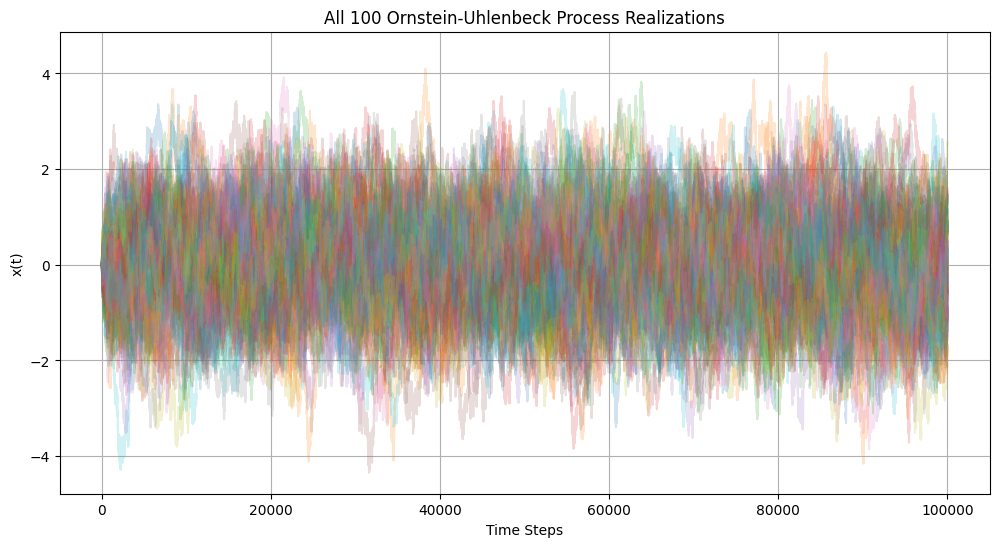

In [ ]:
plt.figure(figsize=(12, 6))
# Plotting all realizations
for i in range(df.shape[1]): # Iterate over all columns
    plt.plot(df.iloc[:, i], label=f'Realization {i+1}', alpha=0.2) # Add alpha for better visualization of many lines

plt.title('All 100 Ornstein-Uhlenbeck Process Realizations')
plt.xlabel('Time Steps')
plt.ylabel('x(t)')
# plt.legend() # Commenting out legend for clarity as there are too many lines
plt.grid(True)
plt.show()

6. Create a function that computes the correlation x(t)x(t + τdt), averages it over t for a given
realization, and then averages over all the realizations in df for a single value τ. Compute
this correlation function over a set of points (at least up to τdt = 2) and compare this with
$\frac{\sigma}{2\omega} e^{
−\omega dtτ}$
.


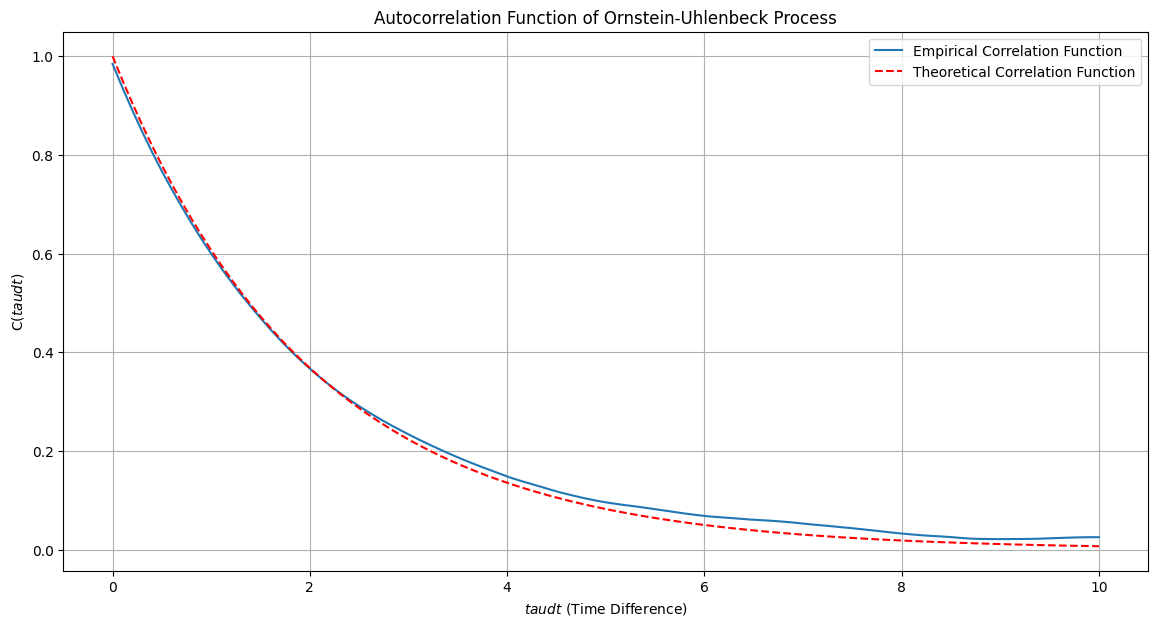

In [ ]:
def compute_autocorrelation(df, omega, sigma, dt, max_tau_dt=2.0, num_points=100):
    """
    Computes the empirical autocorrelation function for the Ornstein-Uhlenbeck process
    from a DataFrame of realizations, and compares it with the theoretical one.

    Args:
        df (pd.DataFrame): DataFrame where each column is a realization and each row is a time point.
        omega (float): Parameter omega of the OU process.
        sigma (float): Parameter sigma of the OU process.
        dt (float): Discretization step.
        max_tau_dt (float): Maximum time difference (tau * dt) to compute the correlation for.
        num_points (int): Number of points to sample for tau_dt up to max_tau_dt.

    Returns:
        tuple: (tau_times, empirical_corr, theoretical_corr)
               tau_times (np.ndarray): Array of actual time differences (tau * dt).
               empirical_corr (np.ndarray): Array of empirical correlation values.
               theoretical_corr (np.ndarray): Array of theoretical correlation values.
    """

    # Determine the maximum number of steps for tau
    max_tau_steps = int(max_tau_dt / dt)

    # Generate a set of tau_steps to evaluate, ensuring we have enough points
    # and that 0 is included, and max_tau_steps is approximately reached.
    if max_tau_steps == 0:
        tau_steps = np.array([0])
    else:
        tau_steps = np.unique(np.linspace(0, max_tau_steps, num_points, dtype=int))
        if max_tau_steps not in tau_steps and max_tau_steps > 0:
            tau_steps = np.append(tau_steps, max_tau_steps) # Ensure max is included

    empirical_correlations = []

    # Iterate through each tau_step (number of dt intervals)
    for tau_s in tau_steps:
        if tau_s == 0:
            # For tau = 0, correlation is the variance (E[x(t)^2]) in the stationary state
            # We use the mean of x^2 over all data, as mean x is 0.
            corr_at_zero = (df**2).stack().mean()
            empirical_correlations.append(corr_at_zero)
        else:
            # Calculate x(t) * x(t + tau_s*dt) for all realizations and average over t, then over realizations
            # Shift the DataFrame to align x(t+tau) with x(t)
            df_shifted = df.shift(-tau_s)
            # Compute the product x(t) * x(t + tau) and take the mean over available values
            # This averages over time for each realization, then averages these averages over all realizations
            correlation_for_tau_s = (df * df_shifted).mean().mean()
            empirical_correlations.append(correlation_for_tau_s)

    tau_times = tau_steps * dt # Convert tau_steps to actual time differences

    # Calculate the theoretical correlation function
    # C_stationary(tau) = (sigma^2 / (2*omega)) * exp(-omega * |tau|)
    # Assuming the process is stationary and x(0)=0
    theoretical_correlations = (sigma**2 / (2 * omega)) * np.exp(-omega * tau_times)

    return tau_times, np.array(empirical_correlations), theoretical_correlations

# --- Execution and Plotting ---

# Ensure df is defined and contains the 100 realizations
# (df is already available from previous cells)

# Compute the correlation function
tau_times, empirical_corr, theoretical_corr = compute_autocorrelation(df, omega, sigma, dt, max_tau_dt=10.0, num_points=100)

# Plotting
plt.figure(figsize=(14, 7))
plt.plot(tau_times, empirical_corr, label='Empirical Correlation Function')
plt.plot(tau_times, theoretical_corr, 'r--', label='Theoretical Correlation Function')

plt.title('Autocorrelation Function of Ornstein-Uhlenbeck Process')
plt.xlabel('$tau dt$ (Time Difference)')
plt.ylabel('C($tau dt$)')
plt.legend()
plt.grid(True)
plt.show()

Here, i've been told to compute the correlation up to taudt=2, but i decided to do it up to 10.

7. Compute the variogram V(τ) of the Ornstein-Uhlenbeck process, as well as the volatility signature plot V(τ)/τ. Compare it to the fBM. What do you notice?


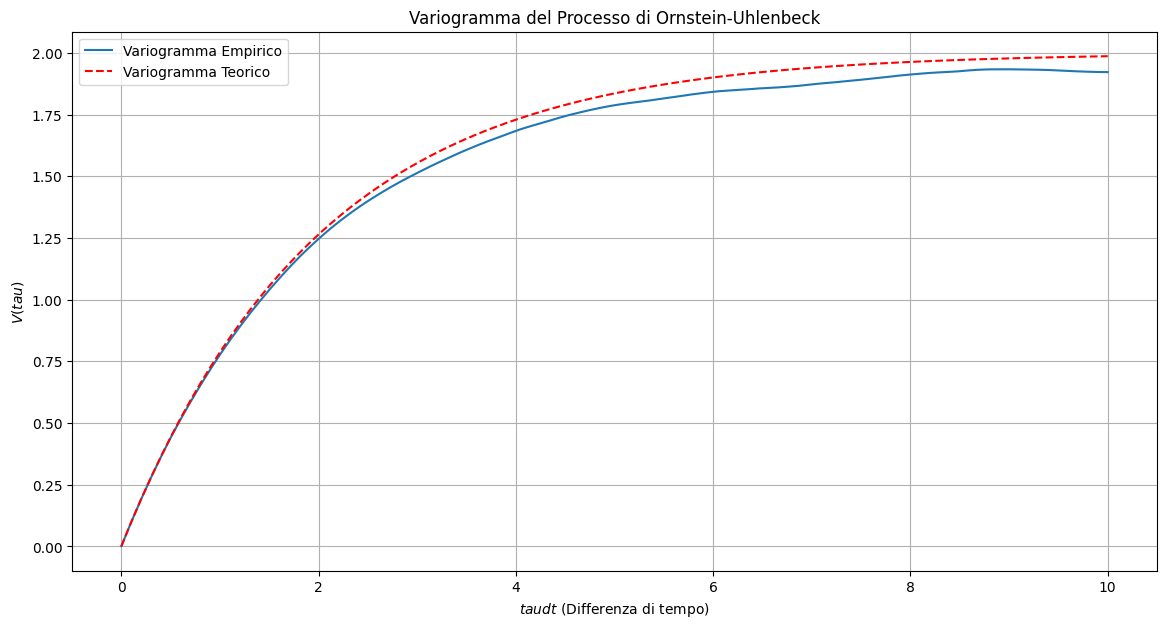

In [ ]:
def compute_variogram(df, dt, max_tau_dt=10.0, num_points=100):
    """
    Computes the empirical variogram for the Ornstein-Uhlenbeck process
    from a DataFrame of realizations.

    Args:
        df (pd.DataFrame): DataFrame where each column is a realization and each row is a time point.
        dt (float): Discretization step.
        max_tau_dt (float): Maximum time difference (tau * dt) to compute the variogram for.
        num_points (int): Number of points to sample for tau_dt up to max_tau_dt.

    Returns:
        tuple: (tau_times, empirical_variogram)
               tau_times (np.ndarray): Array of actual time differences (tau * dt).
               empirical_variogram (np.ndarray): Array of empirical variogram values.
    """
    max_tau_steps = int(max_tau_dt / dt)

    if max_tau_steps == 0:
        tau_steps = np.array([0])
    else:
        tau_steps = np.unique(np.linspace(1, max_tau_steps, num_points, dtype=int))
        if max_tau_steps not in tau_steps and max_tau_steps > 0:
            tau_steps = np.append(tau_steps, max_tau_steps)

    empirical_variograms = []

    for tau_s in tau_steps:
        # Calculate (X(t+tau) - X(t))^2
        # Shift the DataFrame to get X(t+tau)
        df_shifted = df.shift(-tau_s)
        # Compute the squared difference (X(t+tau) - X(t))^2
        diff_squared = (df_shifted - df)**2
        # Average over time (rows) and then over realizations (columns)
        variogram_for_tau_s = diff_squared.mean().mean()
        empirical_variograms.append(variogram_for_tau_s)

    tau_times = tau_steps * dt
    return tau_times, np.array(empirical_variograms)

def theoretical_variogram(tau_times, omega, sigma):
    """
    Computes the theoretical variogram for the Ornstein-Uhlenbeck process.

    Args:
        tau_times (np.ndarray): Array of time differences (tau * dt).
        omega (float): Parameter omega of the OU process.
        sigma (float): Parameter sigma of the OU process.

    Returns:
        np.ndarray: Array of theoretical variogram values.
    """
    # V(tau) = (sigma^2 / omega) * (1 - exp(-omega * |tau|))
    return (sigma**2 / omega) * (1 - np.exp(-omega * tau_times))

# --- Execution and Plotting for Variogram ---

# Compute empirical variogram
tau_times_v, empirical_var = compute_variogram(df, dt, max_tau_dt=10.0, num_points=100)

# Compute theoretical variogram
theoretical_var = theoretical_variogram(tau_times_v, omega, sigma)

# Plotting Variogram
plt.figure(figsize=(14, 7))
plt.plot(tau_times_v, empirical_var, label='Variogram from data')
plt.plot(tau_times_v, theoretical_var, 'r--', label='Variogram from theory')
plt.title('Variogram Ornstein-Uhlenbeck')
plt.xlabel('$tau dt$')
plt.ylabel('$V(tau)$')
plt.legend()
plt.grid(True)
plt.show()

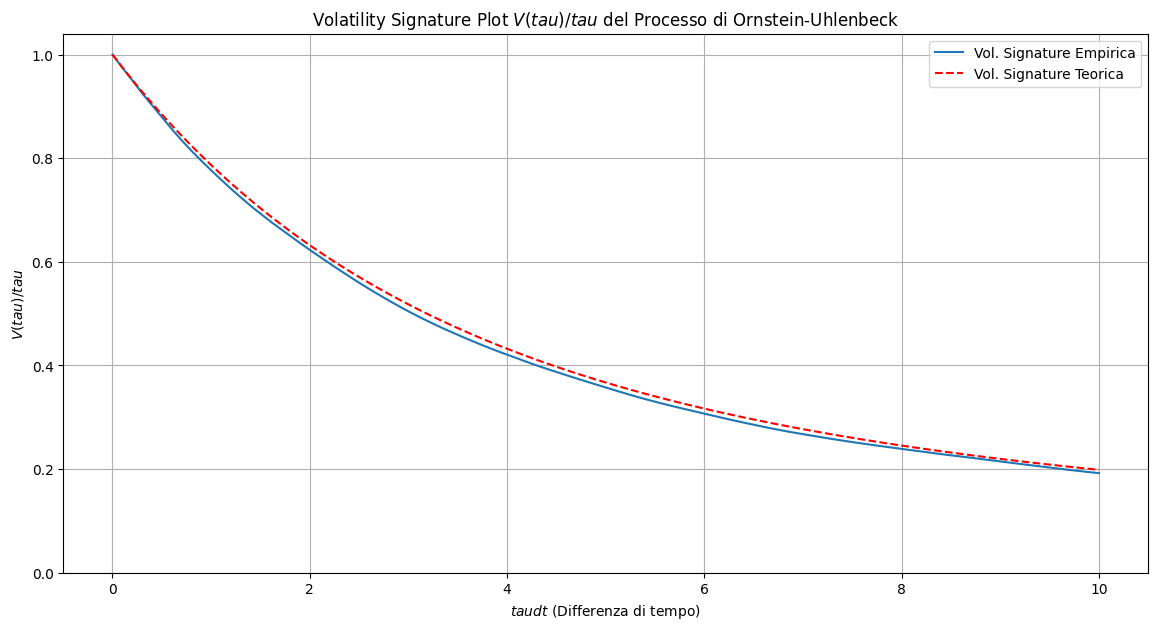

In [ ]:
# --- Volatility Signature Plot V(τ)/τ ---

# Empirical Volatility Signature
# Avoid division by zero for tau_times_v[0] if it's 0
empirical_vs = empirical_var / tau_times_v
empirical_vs[0] = (sigma**2) # Limit as tau -> 0 is sigma^2 (from V(tau) approx sigma^2 * tau)

# Theoretical Volatility Signature
theoretical_vs = theoretical_var / tau_times_v
theoretical_vs[0] = (sigma**2) # Limit as tau -> 0 is sigma^2

# Plotting Volatility Signature
plt.figure(figsize=(14, 7))
plt.plot(tau_times_v, empirical_vs, label='Vol. Signature Empirica')
plt.plot(tau_times_v, theoretical_vs, 'r--', label='Vol. Signature Teorica')
plt.title('Volatility Signature Plot $V(tau)/tau$ del Processo di Ornstein-Uhlenbeck')
plt.xlabel('$tau dt$ (Differenza di tempo)')
plt.ylabel('$V(tau)/tau$')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0) # Ensure y-axis starts from 0 or above
plt.show()

VARIOGRAM: statistical squared distance in target space between the field valuated at two points distant tau from each others
$$ \mathcal{V}_X(\tau) = \langle [X(t+\tau) - X(t)]^2 \rangle $$

AUTOCORRELATION: statistical two point function, probability of observing the two field values at the two points
$$ \mathcal{A}_X(\tau) = \langle X(t+\tau)X(t) \rangle $$

*we have functions of one variable because we are assuming time translation invariance*

Here is what I observe: in the OU process, the variogram stabilizes, whereas in fBM, it grows monotonically—a consequence of the mean-reverting property inherent to OU but absent in fBM. Regarding the volatility signature plot, the OU curve decays toward zero, while the fBM curve asymptotically approaches a non-zero value. Manifestly, the OU process aligns more closely with subdiffusive fBM than with superdiffusive fBM.

8. Recasting the equation in a Langevin form
dx(t)
dt
= −U
0
(x(t)) + σξ(t), (9.14)
can you provide an intuitive explanation for the variogram you just obtained? Draw a sketch!
Bonus: can you give the steady state probability distribution of the particle’s position at a glance?

in this form, it means $U(x)=\frac{\omega}{2}x^2$, where $\omega$ decides the steepness of the pontential that attracts to zero. At the same time, statistical oscilaltions with widness $\sigma$ move it away from zero. The process stabilizes when they balance each others, saturating the variogram to a stable value.

the probabiity distribution is given by $U(x)$.